# Discharge Time Series - EDA & Cleaning

## 📖 Summary

This notebook explores the **14 discharge stations** (2016-2024), including 2 calculated stations (Waal and IJssel via mass balance), to understand data distributions, validate calculations, identify outliers, and apply informed cleaning decisions.

**Input:** `timeseries/discharge/*.parquet` (14 files, includes calculated)

**Output:** `timeseries/cleaned/discharge/*.parquet` (14 cleaned files) + cleaning report

## 🎯 Objectives

1. **Understand discharge patterns** - Flow ranges, seasonal variability
2. **Validate calculated stations** - Waal & IJssel mass balance checks
3. **Identify outliers** - Negative flows, impossible spikes
4. **Define cleaning rules** - Based on hydrology + statistics
5. **Apply cleaning** - Remove bad data with documentation
6. **Validate results** - Confirm data quality improvements

## 📋 Analysis Flow

**Part 1: Exploratory Data Analysis**
1. Load all station data (direct + calculated)
2. Overall distribution analysis
3. Validate Waal & IJssel calculations
4. Station-by-station comparison
5. Temporal patterns (seasonal, flow duration)
6. Outlier identification

**Part 2: Define Cleaning Rules**
7. Domain knowledge (flow physics)
8. Statistical outlier thresholds
9. Document rationale

**Part 3: Apply Cleaning**
10. Execute cleaning with logging
11. Track removed values

**Part 4: Validation**
12. Before/after comparisons
13. Generate cleaning report
14. Save cleaned data

---

## 1. Setup & Configuration

In [5]:
# Imports
import sys
sys.path.insert(0, "..")
sys.path.append("../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

print("✅ Imports successful!")

✅ Imports successful!


In [6]:
# Import paths
import src.paths as PATHS

In [7]:
# Configuration — try multiple possible data locations
_CANDIDATE_RAW_DIRS = [
    PATHS.DATA_DIR / "water_stations_timeseries" / "discharge",
    PATHS.DATA_DIR / "timeseries" / "discharge",
]
RAW_DIR = None
for d in _CANDIDATE_RAW_DIRS:
    if d.exists() and list(d.glob("*.parquet")):
        RAW_DIR = d
        break
if RAW_DIR is None:
    RAW_DIR = _CANDIDATE_RAW_DIRS[0]  # default for path display

OUTPUT_DIR = PATHS.DATA_DIR / "water_stations_timeseries" / "cleaned" / "discharge"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR = PATHS.DATA_DIR / "water_stations_timeseries" / "cleaning_reports"
REPORT_DIR.mkdir(exist_ok=True)

# Calculated stations
CALCULATED_STATIONS = ['millingenaanderijn', 'westervoort']

print(f"📂 Raw data: {RAW_DIR}")
print(f"📁 Output: {OUTPUT_DIR}")
print(f"📊 Reports: {REPORT_DIR}")
print(f"🧮 Calculated stations: {CALCULATED_STATIONS}")

📂 Raw data: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/timeseries/discharge
📁 Output: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/discharge
📊 Reports: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports
🧮 Calculated stations: ['millingenaanderijn', 'westervoort']


---
# Part 1: Exploratory Data Analysis
---

## 2. Load All Discharge Data

In [8]:
print("📥 Loading all discharge station data...\n")

# Get all parquet files
parquet_files = sorted(list(RAW_DIR.glob('*.parquet')))
print(f"Found {len(parquet_files)} station files in {RAW_DIR}\n")

if not parquet_files:
    raise FileNotFoundError(
        f"No discharge parquet files found in {RAW_DIR}.\n"
        "Run 02_bulk_download_timeseries.ipynb first to download the data."
    )

# Load all data
all_data = []
station_info = []

for file in tqdm(parquet_files, desc="Loading stations"):
    df = pd.read_parquet(file)
    station_code = df['station_code'].iloc[0]
    is_calculated = station_code in CALCULATED_STATIONS
    
    all_data.append(df)
    
    station_info.append({
        'station_code': station_code,
        'type': 'calculated' if is_calculated else 'measured',
        'measurements': len(df),
        'min_value': df['discharge_m3s'].min(),
        'max_value': df['discharge_m3s'].max(),
        'mean_value': df['discharge_m3s'].mean(),
        'std_value': df['discharge_m3s'].std(),
        'negative_count': (df['discharge_m3s'] < 0).sum(),
        'start_date': df['timestamp'].min(),
        'end_date': df['timestamp'].max(),
        'years': df['year'].nunique()
    })

# Combine all data
combined_df = pd.concat(all_data, ignore_index=True)
station_info_df = pd.DataFrame(station_info)

print(f"\n✅ Loaded {len(station_info_df)} stations")
print(f"   • Measured: {(station_info_df['type'] == 'measured').sum()}")
print(f"   • Calculated: {(station_info_df['type'] == 'calculated').sum()}")
print(f"📊 Total measurements: {len(combined_df):,}")
print(f"📅 Date range: {combined_df['timestamp'].min()} to {combined_df['timestamp'].max()}")

📥 Loading all discharge station data...

Found 14 station files in /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/timeseries/discharge



Loading stations: 100%|██████████| 14/14 [00:00<00:00, 40.98it/s]



✅ Loaded 14 stations
   • Measured: 12
   • Calculated: 2
📊 Total measurements: 3,305,789
📅 Date range: 2016-01-01 00:00:00+01:00 to 2024-12-31 23:50:00+01:00


## 3. Overall Distribution Analysis

In [9]:
print("="*80)
print("OVERALL DISCHARGE DISTRIBUTION")
print("="*80)

print(f"\n📊 Summary statistics (m³/s):\n")
print(combined_df['discharge_m3s'].describe())

print(f"\n⚠️  Negative flows: {(combined_df['discharge_m3s'] < 0).sum():,} "
      f"({(combined_df['discharge_m3s'] < 0).sum()/len(combined_df)*100:.3f}%)")

print(f"\n📈 Percentiles:\n")
percentiles = [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]
for p in percentiles:
    value = combined_df['discharge_m3s'].quantile(p/100)
    print(f"   {p:5.1f}%: {value:10.2f} m³/s")

OVERALL DISCHARGE DISTRIBUTION

📊 Summary statistics (m³/s):

count    3.305789e+06
mean     4.257678e+35
std      6.511181e+36
min     -4.590000e+02
25%      4.887000e+01
50%      1.812200e+02
75%      5.473000e+02
max      9.999990e+37
Name: discharge_m3s, dtype: float64

⚠️  Negative flows: 196,949 (5.958%)

📈 Percentiles:

     0.1%:    -281.14 m³/s
     1.0%:    -193.00 m³/s
     5.0%:     -10.50 m³/s
    25.0%:      48.87 m³/s
    50.0%:     181.22 m³/s
    75.0%:     547.30 m³/s
    95.0%:    2163.46 m³/s
    99.0%:    4642.23 m³/s
    99.9%: 99999900000000004159462354073616908288.00 m³/s


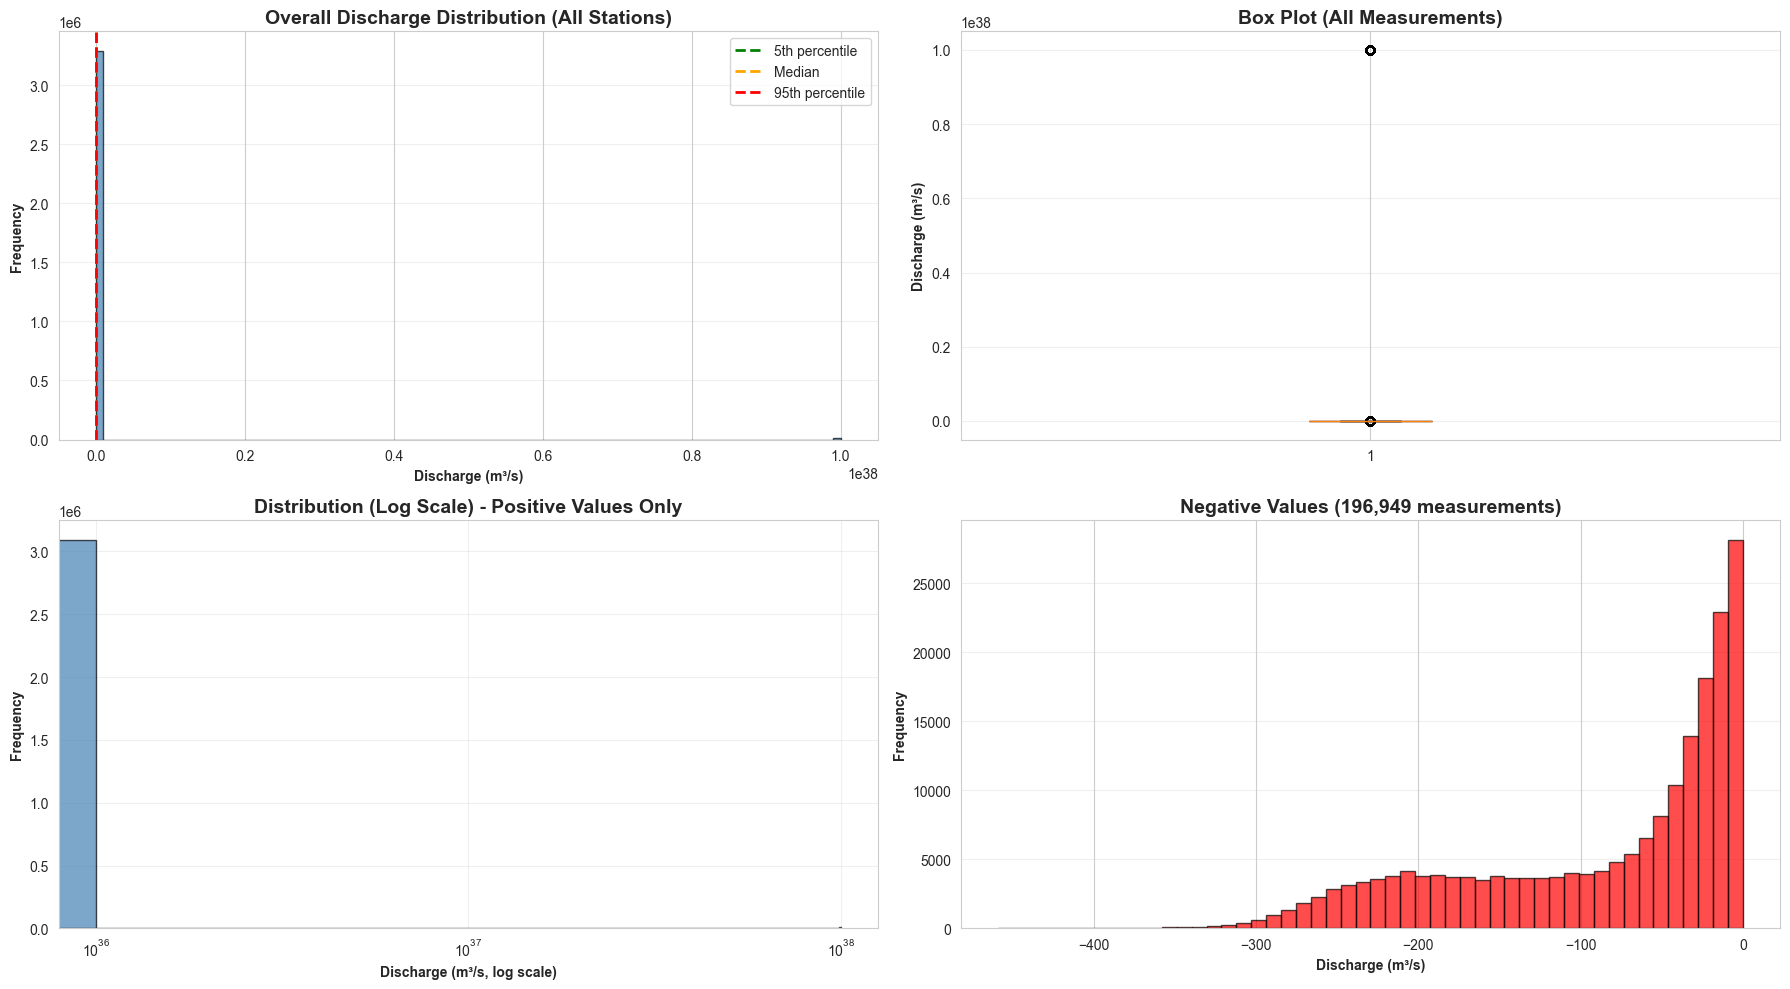

In [10]:
# Visualization: Overall distribution
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Histogram
ax1 = axes[0, 0]
ax1.hist(combined_df['discharge_m3s'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(combined_df['discharge_m3s'].quantile(0.05), color='green', linestyle='--', linewidth=2, label='5th percentile')
ax1.axvline(combined_df['discharge_m3s'].quantile(0.50), color='orange', linestyle='--', linewidth=2, label='Median')
ax1.axvline(combined_df['discharge_m3s'].quantile(0.95), color='red', linestyle='--', linewidth=2, label='95th percentile')
ax1.set_xlabel('Discharge (m³/s)', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Overall Discharge Distribution (All Stations)', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2 = axes[0, 1]
bp = ax2.boxplot(combined_df['discharge_m3s'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
ax2.set_ylabel('Discharge (m³/s)', fontweight='bold')
ax2.set_title('Box Plot (All Measurements)', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Log-scale histogram
ax3 = axes[1, 0]
# Only positive values for log scale
positive_discharge = combined_df[combined_df['discharge_m3s'] > 0]['discharge_m3s']
ax3.hist(positive_discharge, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
ax3.set_xscale('log')
ax3.set_xlabel('Discharge (m³/s, log scale)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Distribution (Log Scale) - Positive Values Only', fontweight='bold', fontsize=14)
ax3.grid(alpha=0.3)

# Negative values
ax4 = axes[1, 1]
negative_discharge = combined_df[combined_df['discharge_m3s'] < 0]
if len(negative_discharge) > 0:
    ax4.hist(negative_discharge['discharge_m3s'], bins=50, edgecolor='black', alpha=0.7, color='red')
    ax4.set_xlabel('Discharge (m³/s)', fontweight='bold')
    ax4.set_ylabel('Frequency', fontweight='bold')
    ax4.set_title(f'Negative Values ({len(negative_discharge):,} measurements)', fontweight='bold', fontsize=14)
    ax4.grid(axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No negative values!', ha='center', va='center', fontsize=16, transform=ax4.transAxes)
    ax4.set_title('Negative Values', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 4. Validate Calculated Stations (Waal & IJssel)

In [11]:
print("="*80)
print("VALIDATION: CALCULATED DISCHARGE STATIONS")
print("="*80)

# Check Waal (Millingen)
if 'millingenaanderijn' in station_info_df['station_code'].values:
    waal_info = station_info_df[station_info_df['station_code'] == 'millingenaanderijn'].iloc[0]
    print(f"\n🌊 WAAL (Millingen a/d Rijn):")
    print(f"   Measurements: {waal_info['measurements']:,}")
    print(f"   Mean discharge: {waal_info['mean_value']:.0f} m³/s")
    print(f"   Range: {waal_info['min_value']:.0f} - {waal_info['max_value']:.0f} m³/s")
    print(f"   Negative values: {waal_info['negative_count']:,}")
    print(f"   Expected: ~67% of Rhine flow (~2500 m³/s typical)")
    print(f"   Status: {'✅ Looks good!' if waal_info['mean_value'] > 1000 and waal_info['negative_count'] == 0 else '⚠️  Check required'}")

# Check IJssel (Westervoort)
if 'westervoort' in station_info_df['station_code'].values:
    ijssel_info = station_info_df[station_info_df['station_code'] == 'westervoort'].iloc[0]
    print(f"\n🌊 IJSSEL (Westervoort):")
    print(f"   Measurements: {ijssel_info['measurements']:,}")
    print(f"   Mean discharge: {ijssel_info['mean_value']:.0f} m³/s")
    print(f"   Range: {ijssel_info['min_value']:.0f} - {ijssel_info['max_value']:.0f} m³/s")
    print(f"   Negative values: {ijssel_info['negative_count']:,}")
    print(f"   Expected: Variable (weir-controlled), typically 200-600 m³/s")
    print(f"   Status: {'✅ Looks good!' if ijssel_info['mean_value'] > 100 and ijssel_info['negative_count'] == 0 else '⚠️  Check required'}")

VALIDATION: CALCULATED DISCHARGE STATIONS

🌊 WAAL (Millingen a/d Rijn):
   Measurements: 3,086
   Mean discharge: 648087491898898362526353339803762688 m³/s
   Range: 541 - 99999900000000004159462354073616908288 m³/s
   Negative values: 0
   Expected: ~67% of Rhine flow (~2500 m³/s typical)
   Status: ✅ Looks good!

🌊 IJSSEL (Westervoort):
   Measurements: 2,556
   Mean discharge: 156494366197183112924147101797974016 m³/s
   Range: 12 - 99999900000000004159462354073616908288 m³/s
   Negative values: 0
   Expected: Variable (weir-controlled), typically 200-600 m³/s
   Status: ✅ Looks good!


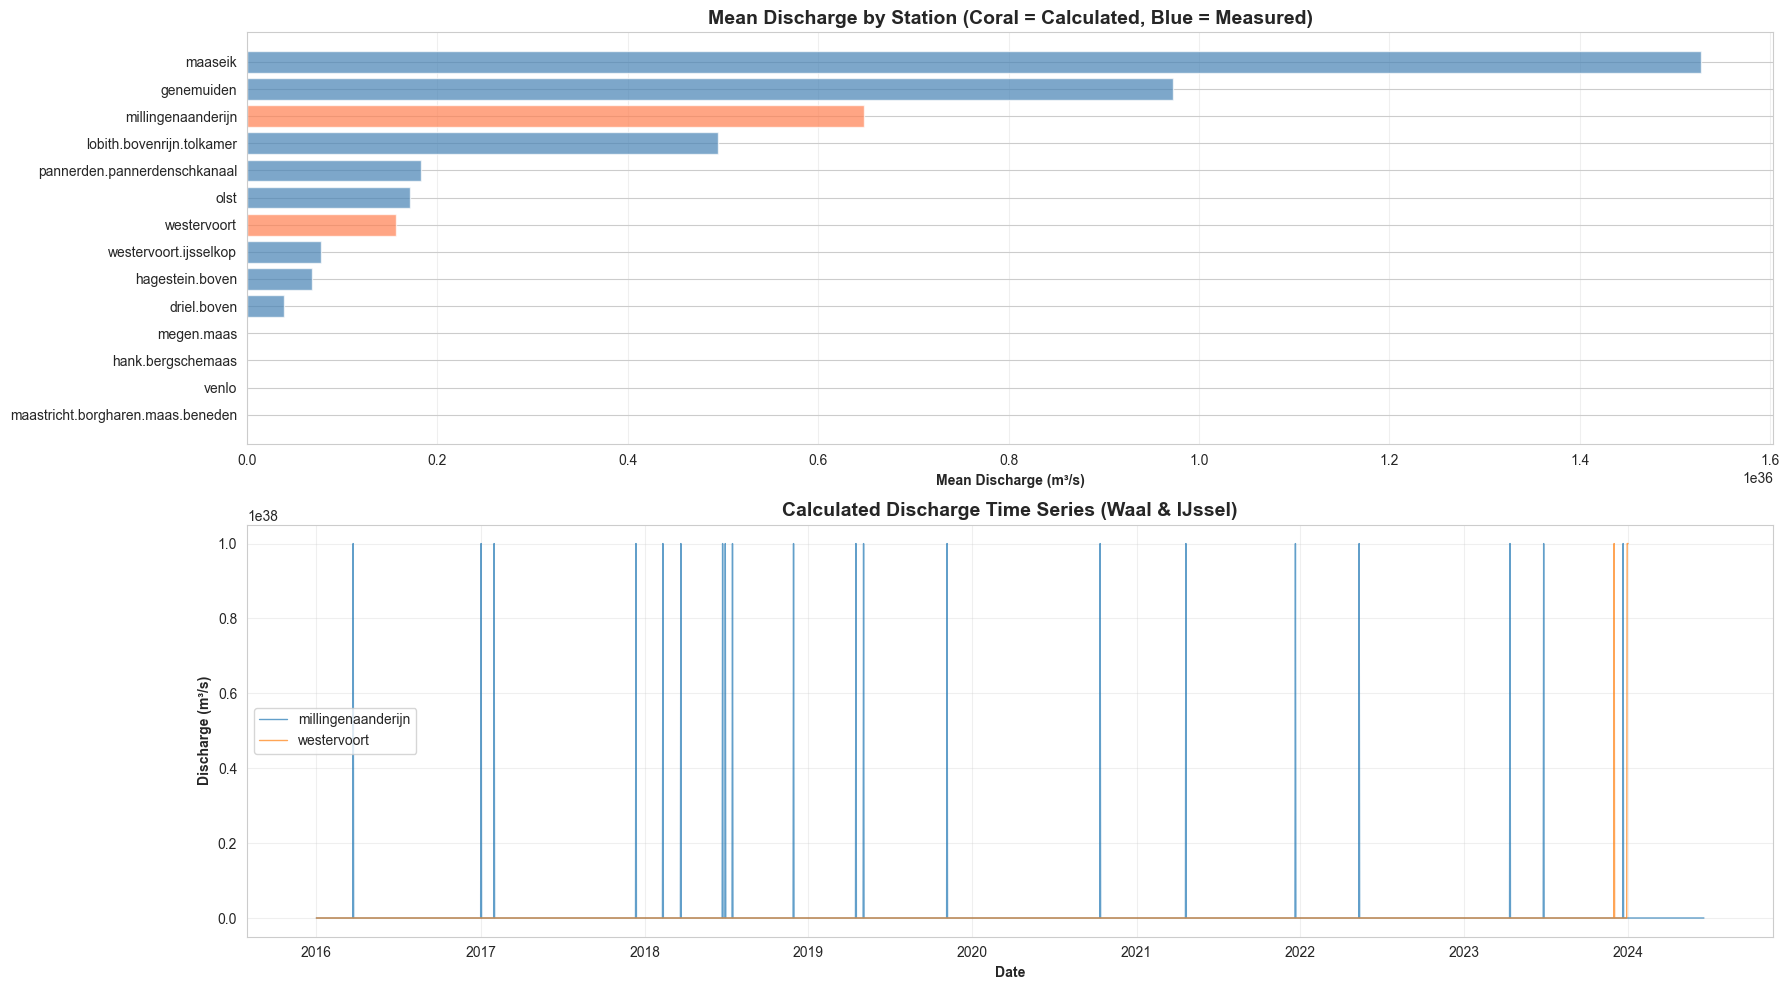

In [12]:
# Visualization: Calculated vs measured stations
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Mean discharge comparison
ax1 = axes[0]
colors = ['coral' if t == 'calculated' else 'steelblue' for t in station_info_df['type']]
station_info_sorted = station_info_df.sort_values('mean_value')
bars = ax1.barh(range(len(station_info_sorted)), station_info_sorted['mean_value'], 
                color=[colors[station_info_df.index.get_loc(idx)] for idx in station_info_sorted.index], 
                alpha=0.7)
ax1.set_yticks(range(len(station_info_sorted)))
ax1.set_yticklabels(station_info_sorted['station_code'], fontsize=10)
ax1.set_xlabel('Mean Discharge (m³/s)', fontweight='bold')
ax1.set_title('Mean Discharge by Station (Coral = Calculated, Blue = Measured)', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)

# Time series for calculated stations
ax2 = axes[1]
for calc_station in CALCULATED_STATIONS:
    calc_df = combined_df[combined_df['station_code'] == calc_station].sort_values('timestamp')
    if len(calc_df) > 0:
        # Sample for performance
        sample_idx = np.arange(0, len(calc_df), max(1, len(calc_df)//5000))
        sample = calc_df.iloc[sample_idx]
        ax2.plot(sample['timestamp'], sample['discharge_m3s'], label=calc_station, linewidth=1, alpha=0.7)

ax2.set_xlabel('Date', fontweight='bold')
ax2.set_ylabel('Discharge (m³/s)', fontweight='bold')
ax2.set_title('Calculated Discharge Time Series (Waal & IJssel)', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Station-by-Station Summary

In [13]:
print("="*80)
print("STATION-BY-STATION SUMMARY")
print("="*80)

print(f"\n📊 All stations overview:\n")
print(station_info_df[['station_code', 'type', 'mean_value', 'min_value', 'max_value', 'negative_count']].to_string(index=False))

print(f"\n📊 Stations with negative values:\n")
has_negatives = station_info_df[station_info_df['negative_count'] > 0]
if len(has_negatives) > 0:
    print(has_negatives[['station_code', 'negative_count', 'measurements']].to_string(index=False))
    print(f"\n   Total: {len(has_negatives)} stations with negative values")
else:
    print("   None! ✅")

STATION-BY-STATION SUMMARY

📊 All stations overview:

                     station_code       type   mean_value  min_value    max_value  negative_count
                      driel.boven   measured 3.907773e+34      -0.20 9.999990e+37               2
                       genemuiden   measured 9.722776e+35    -263.00 9.999990e+37           89846
                  hagestein.boven   measured 6.842278e+34     -17.00 9.999990e+37             133
                hank.bergschemaas   measured 3.003546e+02    -459.00 2.314000e+03          103983
        lobith.bovenrijn.tolkamer   measured 4.947087e+35     708.82 9.999990e+37               0
                          maaseik   measured 1.527016e+36       9.32 9.999990e+37               0
maastricht.borgharen.maas.beneden   measured 2.350413e+02       8.00 3.284000e+03               0
                       megen.maas   measured 3.005459e+02     -83.57 2.328000e+03            2932
               millingenaanderijn calculated 6.480875e+35     54

## 6. Temporal Patterns

In [14]:
# Add temporal features
combined_df['month'] = combined_df['timestamp'].dt.month
combined_df['season'] = combined_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

print("="*80)
print("TEMPORAL PATTERNS")
print("="*80)

print(f"\n📊 Mean discharge by year:\n")
yearly_mean = combined_df.groupby('year')['discharge_m3s'].mean()
print(yearly_mean)

print(f"\n📊 Mean discharge by season:\n")
seasonal_mean = combined_df.groupby('season')['discharge_m3s'].mean().sort_values(ascending=False)
print(seasonal_mean)

TEMPORAL PATTERNS

📊 Mean discharge by year:

year
2016    7.612580e+35
2017    3.349750e+35
2018    8.270500e+35
2019    1.724811e+35
2020    2.756464e+35
2021    2.119130e+35
2022    3.870703e+35
2023    7.144952e+35
2024    1.218436e+35
Name: discharge_m3s, dtype: float64

📊 Mean discharge by season:

season
Winter    5.172104e+35
Summer    4.916647e+35
Spring    3.614451e+35
Fall      3.332865e+35
Name: discharge_m3s, dtype: float64


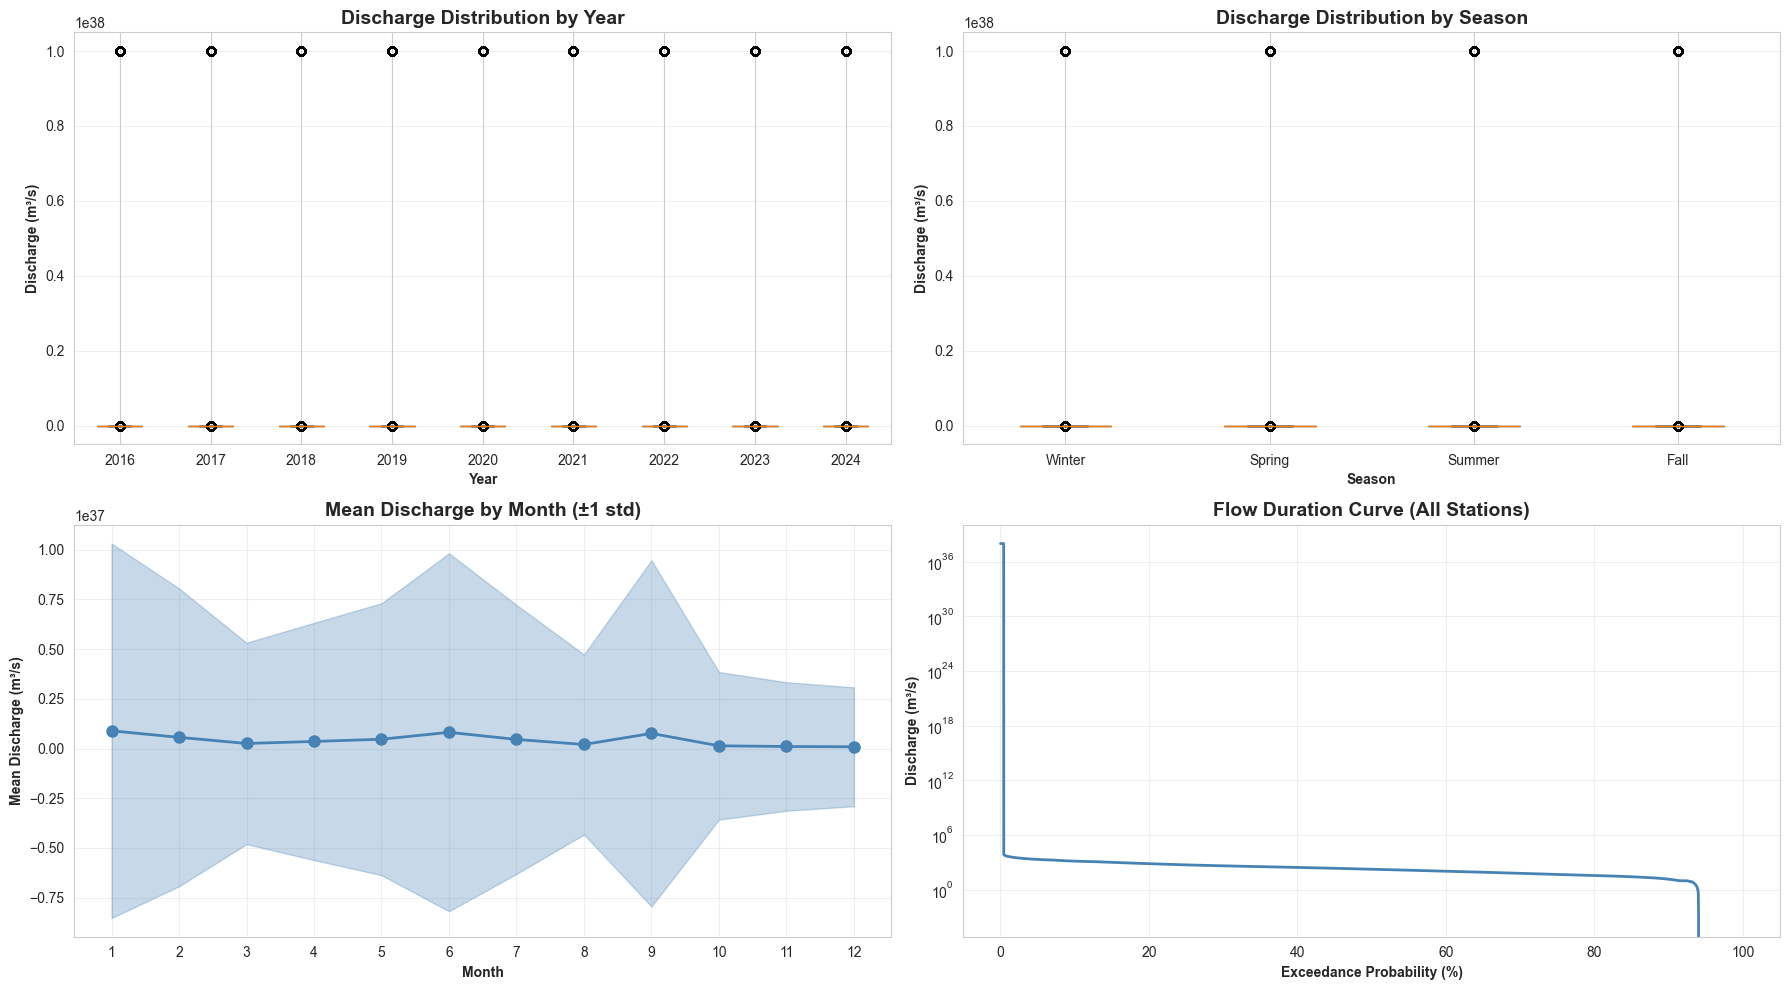

In [15]:
# Visualization: Temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Year-by-year
ax1 = axes[0, 0]
years = sorted(combined_df['year'].unique())
data_by_year = [combined_df[combined_df['year'] == year]['discharge_m3s'].values for year in years]
bp1 = ax1.boxplot(data_by_year, labels=years, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Discharge (m³/s)', fontweight='bold')
ax1.set_title('Discharge Distribution by Year', fontweight='bold', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Seasonal patterns
ax2 = axes[0, 1]
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
data_by_season = [combined_df[combined_df['season'] == season]['discharge_m3s'].values for season in season_order]
bp2 = ax2.boxplot(data_by_season, labels=season_order, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'yellow', 'orange']
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_xlabel('Season', fontweight='bold')
ax2.set_ylabel('Discharge (m³/s)', fontweight='bold')
ax2.set_title('Discharge Distribution by Season', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Monthly patterns
ax3 = axes[1, 0]
monthly_mean = combined_df.groupby('month')['discharge_m3s'].mean()
monthly_std = combined_df.groupby('month')['discharge_m3s'].std()
ax3.plot(monthly_mean.index, monthly_mean.values, marker='o', linewidth=2, markersize=8, color='steelblue')
ax3.fill_between(monthly_mean.index, 
                  monthly_mean.values - monthly_std.values,
                  monthly_mean.values + monthly_std.values,
                  alpha=0.3, color='steelblue')
ax3.set_xlabel('Month', fontweight='bold')
ax3.set_ylabel('Mean Discharge (m³/s)', fontweight='bold')
ax3.set_title('Mean Discharge by Month (±1 std)', fontweight='bold', fontsize=14)
ax3.set_xticks(range(1, 13))
ax3.grid(alpha=0.3)

# Flow duration curve
ax4 = axes[1, 1]
sorted_discharge = np.sort(combined_df['discharge_m3s'].values)[::-1]
exceedance = np.arange(1, len(sorted_discharge)+1) / len(sorted_discharge) * 100
ax4.plot(exceedance, sorted_discharge, linewidth=2, color='steelblue')
ax4.set_xlabel('Exceedance Probability (%)', fontweight='bold')
ax4.set_ylabel('Discharge (m³/s)', fontweight='bold')
ax4.set_title('Flow Duration Curve (All Stations)', fontweight='bold', fontsize=14)
ax4.set_yscale('log')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Outlier Identification

In [18]:
print("="*80)
print("OUTLIER IDENTIFICATION")
print("="*80)

# Method 1: Negative values (physically impossible)
print(f"\n🔍 Method 1: Negative discharge values\n")
outliers_negative = combined_df[combined_df['discharge_m3s'] < 0]
print(f"   Negative values: {len(outliers_negative):,} ({len(outliers_negative)/len(combined_df)*100:.3f}%)")

# Method 2: Domain knowledge (extreme high flows)
print(f"\n🔍 Method 2: Domain knowledge thresholds\n")
# Rhine peak flows rarely exceed 12,000 m³/s at Lobith
# Smaller rivers much less
DOMAIN_MAX = 15000  # m³/s (generous buffer)
outliers_high = combined_df[combined_df['discharge_m3s'] > DOMAIN_MAX]
print(f"   Domain max: {DOMAIN_MAX} m³/s")
print(f"   Outliers found: {len(outliers_high):,} ({len(outliers_high)/len(combined_df)*100:.3f}%)")

# Method 3: IQR-based
print(f"\n🔍 Method 3: IQR-based outliers (upper only)\n")
Q1 = combined_df['discharge_m3s'].quantile(0.25)
Q3 = combined_df['discharge_m3s'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

outliers_iqr = combined_df[combined_df['discharge_m3s'] > upper_bound]
print(f"   Q1 (25%): {Q1:.2f} m³/s")
print(f"   Q3 (75%): {Q3:.2f} m³/s")
print(f"   IQR: {IQR:.2f} m³/s")
print(f"   Upper bound (Q3 + 3×IQR): {upper_bound:.2f} m³/s")
print(f"   Outliers found: {len(outliers_iqr):,} ({len(outliers_iqr)/len(combined_df)*100:.3f}%)")

OUTLIER IDENTIFICATION

🔍 Method 1: Negative discharge values

   Negative values: 196,949 (5.958%)

🔍 Method 2: Domain knowledge thresholds

   Domain max: 15000 m³/s
   Outliers found: 14,075 (0.426%)

🔍 Method 3: IQR-based outliers (upper only)

   Q1 (25%): 48.87 m³/s
   Q3 (75%): 547.30 m³/s
   IQR: 498.43 m³/s
   Upper bound (Q3 + 3×IQR): 2042.59 m³/s
   Outliers found: 185,792 (5.620%)


In [19]:
# Inspect negative values
if len(outliers_negative) > 0:
    print("\n📊 Sample of negative discharge values:\n")
    print(outliers_negative.nsmallest(20, 'discharge_m3s')[['timestamp', 'station_code', 'discharge_m3s', 'year']].to_string(index=False))
    
    print("\n📊 Stations with most negative values:\n")
    neg_counts = outliers_negative.groupby('station_code').size().sort_values(ascending=False)
    print(neg_counts)
else:
    print("\n✅ No negative values found!")


📊 Sample of negative discharge values:

                timestamp      station_code  discharge_m3s  year
2021-10-21 07:30:00+01:00 hank.bergschemaas         -459.0  2021
2021-10-21 07:20:00+01:00 hank.bergschemaas         -458.0  2021
2021-10-21 07:40:00+01:00 hank.bergschemaas         -452.0  2021
2021-10-21 07:10:00+01:00 hank.bergschemaas         -446.0  2021
2021-10-21 07:50:00+01:00 hank.bergschemaas         -446.0  2021
2021-10-21 08:00:00+01:00 hank.bergschemaas         -442.0  2021
2021-10-21 08:10:00+01:00 hank.bergschemaas         -434.0  2021
2023-07-05 09:10:00+01:00 hank.bergschemaas         -431.0  2023
2023-07-05 09:20:00+01:00 hank.bergschemaas         -429.0  2023
2023-07-05 09:00:00+01:00 hank.bergschemaas         -428.0  2023
2021-10-21 07:00:00+01:00 hank.bergschemaas         -426.0  2021
2023-07-05 08:50:00+01:00 hank.bergschemaas         -424.0  2023
2021-10-21 08:20:00+01:00 hank.bergschemaas         -423.0  2021
2023-07-05 07:50:00+01:00 hank.bergschemaas      

---
# Part 2: Define Cleaning Rules
---

## 8. Cleaning Rules Based on EDA

In [20]:
print("="*80)
print("CLEANING RULES DEFINITION")
print("="*80)

print("""
Based on the EDA, we define the following cleaning rules:

🎯 Rule 1: Remove Negative Discharge
   • Minimum: 0 m³/s
   • Rationale: Negative discharge is physically impossible in rivers
   • Likely cause: Mass balance calculation timing mismatches

🎯 Rule 2: Domain Knowledge Upper Limit
   • Maximum: 15,000 m³/s
   • Rationale: Rhine peak flows rarely exceed 12,000 m³/s at Lobith
   • Buffer: 15,000 allows for extreme events

🎯 Rule 3: Remove Duplicate Timestamps
   • Remove any duplicate timestamp entries within a station
   • Rationale: Measurement errors or API artifacts

💡 Conservative Approach:
   We primarily remove physically impossible values (negative flows).
   The upper limit is very generous to preserve extreme flood events,
   which are critical for erosion modeling.

""")

# Define thresholds
CLEAN_MIN = 0      # m³/s
CLEAN_MAX = 15000  # m³/s

print(f"✅ Cleaning thresholds set:")
print(f"   Min value: {CLEAN_MIN} m³/s")
print(f"   Max value: {CLEAN_MAX} m³/s")

CLEANING RULES DEFINITION

Based on the EDA, we define the following cleaning rules:

🎯 Rule 1: Remove Negative Discharge
   • Minimum: 0 m³/s
   • Rationale: Negative discharge is physically impossible in rivers
   • Likely cause: Mass balance calculation timing mismatches

🎯 Rule 2: Domain Knowledge Upper Limit
   • Maximum: 15,000 m³/s
   • Rationale: Rhine peak flows rarely exceed 12,000 m³/s at Lobith
   • Buffer: 15,000 allows for extreme events

🎯 Rule 3: Remove Duplicate Timestamps
   • Remove any duplicate timestamp entries within a station
   • Rationale: Measurement errors or API artifacts

💡 Conservative Approach:
   We primarily remove physically impossible values (negative flows).
   The upper limit is very generous to preserve extreme flood events,
   which are critical for erosion modeling.


✅ Cleaning thresholds set:
   Min value: 0 m³/s
   Max value: 15000 m³/s


---
# Part 3: Apply Cleaning
---

## 9. Clean All Stations

In [21]:
def clean_discharge_data(df, station_code, min_val=0, max_val=15000):
    """
    Clean discharge data for a single station.
    
    Args:
        df: DataFrame with discharge data
        station_code: Station identifier
        min_val: Minimum acceptable value (m³/s)
        max_val: Maximum acceptable value (m³/s)
    
    Returns:
        cleaned_df: Cleaned DataFrame
        cleaning_stats: Dictionary with cleaning statistics
    """
    original_count = len(df)
    df_clean = df.copy()
    
    # Rule 1: Domain constraints
    domain_mask = (df_clean['discharge_m3s'] >= min_val) & (df_clean['discharge_m3s'] <= max_val)
    removed_domain = (~domain_mask).sum()
    removed_negative = (df_clean['discharge_m3s'] < 0).sum()
    removed_high = (df_clean['discharge_m3s'] > max_val).sum()
    df_clean = df_clean[domain_mask].copy()
    
    # Rule 2: Remove duplicates
    before_dup = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['timestamp'], keep='first')
    removed_duplicates = before_dup - len(df_clean)
    
    final_count = len(df_clean)
    total_removed = original_count - final_count
    
    cleaning_stats = {
        'station_code': station_code,
        'type': 'calculated' if station_code in CALCULATED_STATIONS else 'measured',
        'original_count': original_count,
        'final_count': final_count,
        'removed_total': total_removed,
        'removed_negative': removed_negative,
        'removed_high': removed_high,
        'removed_duplicates': removed_duplicates,
        'pct_removed': (total_removed / original_count * 100) if original_count > 0 else 0,
        'min_value': df_clean['discharge_m3s'].min() if len(df_clean) > 0 else None,
        'max_value': df_clean['discharge_m3s'].max() if len(df_clean) > 0 else None,
        'mean_value': df_clean['discharge_m3s'].mean() if len(df_clean) > 0 else None
    }
    
    return df_clean, cleaning_stats

print("✅ Cleaning function defined!")

✅ Cleaning function defined!


In [22]:
print("="*80)
print("CLEANING ALL STATIONS")
print("="*80)

print(f"\n🧹 Processing {len(parquet_files)} stations...\n")

cleaning_results = []

for file in tqdm(parquet_files, desc="Cleaning stations"):
    # Load raw data
    df_raw = pd.read_parquet(file)
    station_code = df_raw['station_code'].iloc[0]
    
    # Clean
    df_clean, stats = clean_discharge_data(df_raw, station_code, CLEAN_MIN, CLEAN_MAX)
    
    # Save cleaned data
    if len(df_clean) > 0:
        output_path = OUTPUT_DIR / f"{station_code}.parquet"
        df_clean.to_parquet(output_path, index=False, compression='snappy')
        stats['status'] = 'success'
        stats['output_path'] = str(output_path)
    else:
        stats['status'] = 'failed_empty'
        stats['output_path'] = 'N/A'
    
    cleaning_results.append(stats)

cleaning_df = pd.DataFrame(cleaning_results)

print("\n✅ Cleaning complete!")

CLEANING ALL STATIONS

🧹 Processing 14 stations...



Cleaning stations: 100%|██████████| 14/14 [00:00<00:00, 16.80it/s]


✅ Cleaning complete!


---
# Part 4: Validation & Reporting
---

## 10. Cleaning Summary

In [23]:
print("="*80)
print("CLEANING SUMMARY")
print("="*80)

total_original = cleaning_df['original_count'].sum()
total_final = cleaning_df['final_count'].sum()
total_removed = cleaning_df['removed_total'].sum()

print(f"\n📊 Overall Statistics:\n")
print(f"   Original measurements: {total_original:,}")
print(f"   Final measurements: {total_final:,}")
print(f"   Removed: {total_removed:,} ({total_removed/total_original*100:.3f}%)\n")

print(f"📊 Breakdown by removal reason:\n")
print(f"   Negative values: {cleaning_df['removed_negative'].sum():,}")
print(f"   Too high (>{CLEAN_MAX}): {cleaning_df['removed_high'].sum():,}")
print(f"   Duplicates: {cleaning_df['removed_duplicates'].sum():,}\n")

print(f"📊 By station type:\n")
for stype in ['measured', 'calculated']:
    subset = cleaning_df[cleaning_df['type'] == stype]
    print(f"   {stype.capitalize()}:")
    print(f"      Stations: {len(subset)}")
    print(f"      Removed: {subset['removed_total'].sum():,} ({subset['removed_total'].sum()/subset['original_count'].sum()*100:.3f}%)\n")

print(f"📊 Stations by removal percentage:\n")
print(cleaning_df[['station_code', 'type', 'pct_removed']].sort_values('pct_removed', ascending=False).to_string(index=False))

CLEANING SUMMARY

📊 Overall Statistics:

   Original measurements: 3,305,789
   Final measurements: 3,094,765
   Removed: 211,024 (6.383%)

📊 Breakdown by removal reason:

   Negative values: 196,949
   Too high (>15000): 14,075
   Duplicates: 0

📊 By station type:

   Measured:
      Stations: 12
      Removed: 211,000 (6.394%)

   Calculated:
      Stations: 2
      Removed: 24 (0.425%)

📊 Stations by removal percentage:

                     station_code       type  pct_removed
                hank.bergschemaas   measured    21.961806
                       genemuiden   measured    19.950193
                  hagestein.boven   measured     4.618543
                          maaseik   measured     1.527017
               millingenaanderijn calculated     0.648088
                       megen.maas   measured     0.619255
        lobith.bovenrijn.tolkamer   measured     0.494709
     pannerden.pannerdenschkanaal   measured     0.182482
                             olst   measured     0

## 11. Before/After Comparison

In [24]:
# Load cleaned data
print("Loading cleaned data for comparison...\n")

cleaned_files = sorted(list(OUTPUT_DIR.glob('*.parquet')))
all_cleaned_data = []

for file in tqdm(cleaned_files, desc="Loading cleaned data"):
    df = pd.read_parquet(file)
    all_cleaned_data.append(df)

cleaned_combined = pd.concat(all_cleaned_data, ignore_index=True)

print(f"✅ Loaded {len(cleaned_combined):,} cleaned measurements")

Loading cleaned data for comparison...



Loading cleaned data: 100%|██████████| 14/14 [00:00<00:00, 92.02it/s]


✅ Loaded 3,094,765 cleaned measurements


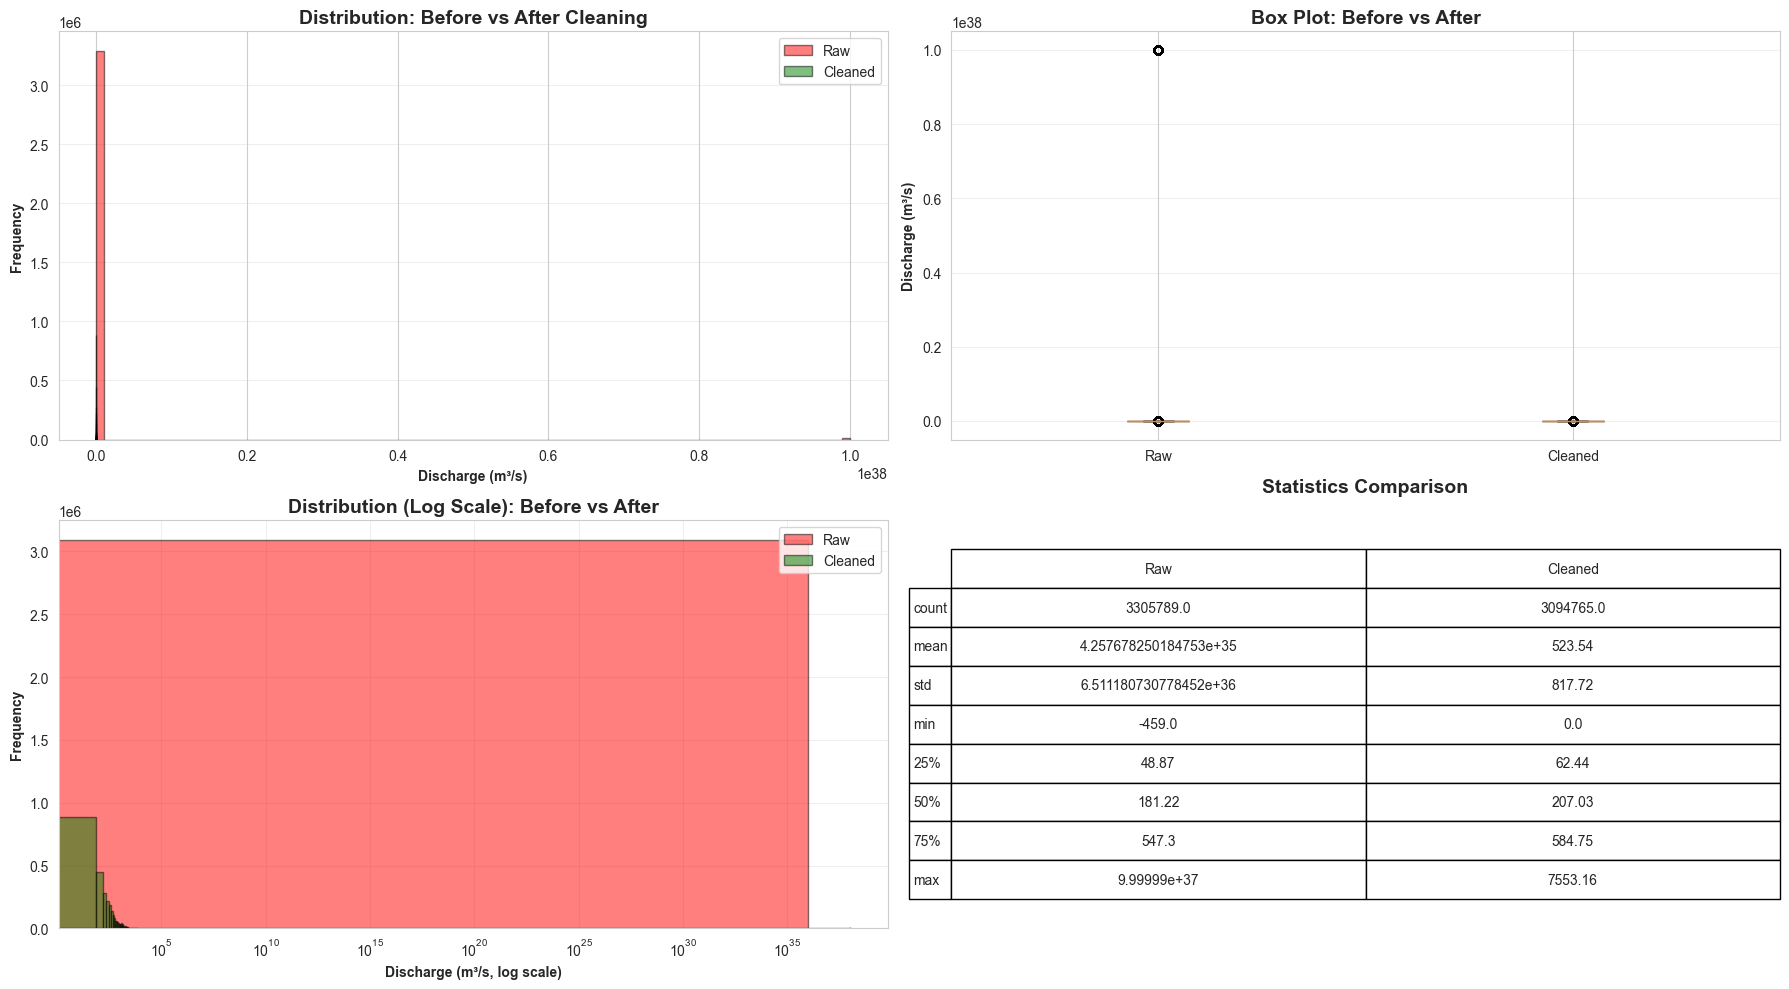

In [25]:
# Visualization: Before/After
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Histogram comparison
ax1 = axes[0, 0]
ax1.hist(combined_df['discharge_m3s'], bins=100, alpha=0.5, label='Raw', color='red', edgecolor='black')
ax1.hist(cleaned_combined['discharge_m3s'], bins=100, alpha=0.5, label='Cleaned', color='green', edgecolor='black')
ax1.set_xlabel('Discharge (m³/s)', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Distribution: Before vs After Cleaning', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot comparison
ax2 = axes[0, 1]
bp = ax2.boxplot([combined_df['discharge_m3s'], cleaned_combined['discharge_m3s']], 
                  labels=['Raw', 'Cleaned'], patch_artist=True)
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('green')
ax2.set_ylabel('Discharge (m³/s)', fontweight='bold')
ax2.set_title('Box Plot: Before vs After', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

# Log-scale comparison
ax3 = axes[1, 0]
positive_raw = combined_df[combined_df['discharge_m3s'] > 0]['discharge_m3s']
ax3.hist(positive_raw, bins=100, alpha=0.5, label='Raw', color='red', edgecolor='black')
ax3.hist(cleaned_combined['discharge_m3s'], bins=100, alpha=0.5, label='Cleaned', color='green', edgecolor='black')
ax3.set_xscale('log')
ax3.set_xlabel('Discharge (m³/s, log scale)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Distribution (Log Scale): Before vs After', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(alpha=0.3)

# Statistics table
ax4 = axes[1, 1]
stats_comparison = pd.DataFrame({
    'Raw': combined_df['discharge_m3s'].describe(),
    'Cleaned': cleaned_combined['discharge_m3s'].describe()
})
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=stats_comparison.values.round(2),
                  rowLabels=stats_comparison.index,
                  colLabels=stats_comparison.columns,
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax4.set_title('Statistics Comparison', fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

## 12. Generate Cleaning Report

In [26]:
print("="*80)
print("SAVING CLEANING REPORT")
print("="*80)

# Save detailed report
report_path = REPORT_DIR / "discharge_cleaning_report.csv"
cleaning_df.to_csv(report_path, index=False)
print(f"\n✅ Detailed report saved: {report_path}")

# Save summary
summary_path = REPORT_DIR / "discharge_cleaning_summary.txt"
with open(summary_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("DISCHARGE CLEANING SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(f"Date: {pd.Timestamp.now()}\n\n")
    f.write(f"Stations processed: {len(cleaning_df)}\n")
    f.write(f"  - Measured: {(cleaning_df['type'] == 'measured').sum()}\n")
    f.write(f"  - Calculated: {(cleaning_df['type'] == 'calculated').sum()}\n\n")
    f.write(f"Original measurements: {total_original:,}\n")
    f.write(f"Final measurements: {total_final:,}\n")
    f.write(f"Removed: {total_removed:,} ({total_removed/total_original*100:.3f}%)\n\n")
    f.write("Removal breakdown:\n")
    f.write(f"  - Negative values: {cleaning_df['removed_negative'].sum():,}\n")
    f.write(f"  - Too high: {cleaning_df['removed_high'].sum():,}\n")
    f.write(f"  - Duplicates: {cleaning_df['removed_duplicates'].sum():,}\n\n")
    f.write("Cleaning rules:\n")
    f.write(f"  - Min value: {CLEAN_MIN} m³/s\n")
    f.write(f"  - Max value: {CLEAN_MAX} m³/s\n\n")
    f.write("Statistics (cleaned data):\n")
    f.write(cleaned_combined['discharge_m3s'].describe().to_string())

print(f"✅ Summary saved: {summary_path}")

print(f"\n📂 Cleaned data location: {OUTPUT_DIR}")
print(f"📦 Files created: {len(list(OUTPUT_DIR.glob('*.parquet')))}")

SAVING CLEANING REPORT

✅ Detailed report saved: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports/discharge_cleaning_report.csv
✅ Summary saved: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports/discharge_cleaning_summary.txt

📂 Cleaned data location: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/discharge
📦 Files created: 14


## 13. Final Validation

In [27]:
print("="*80)
print("FINAL VALIDATION")
print("="*80)

print(f"\n✅ Quality checks:\n")

# Check 1: No negative values
negatives = (cleaned_combined['discharge_m3s'] < 0).sum()
print(f"1. No negative discharge:")
print(f"   {'✅ PASS' if negatives == 0 else '❌ FAIL'} - {negatives} negative values\n")

# Check 2: All values within domain
out_of_range = cleaned_combined[cleaned_combined['discharge_m3s'] > CLEAN_MAX]
print(f"2. Values within domain [0, {CLEAN_MAX}]:")
print(f"   {'✅ PASS' if len(out_of_range) == 0 else '❌ FAIL'} - {len(out_of_range)} out-of-range values\n")

# Check 3: No duplicates
duplicates = cleaned_combined.groupby('station_code')['timestamp'].apply(lambda x: x.duplicated().sum()).sum()
print(f"3. No duplicate timestamps:")
print(f"   {'✅ PASS' if duplicates == 0 else '❌ FAIL'} - {duplicates} duplicates found\n")

# Check 4: Calculated stations still present
calc_present = set(CALCULATED_STATIONS).issubset(set(cleaned_combined['station_code'].unique()))
print(f"4. Calculated stations retained:")
print(f"   {'✅ PASS' if calc_present else '❌ FAIL'}")
for calc_station in CALCULATED_STATIONS:
    count = (cleaned_combined['station_code'] == calc_station).sum()
    print(f"      • {calc_station}: {count:,} measurements\n")

# Check 5: Data retention
retention_rate = (total_final / total_original) * 100
print(f"5. Data retention rate:")
print(f"   {retention_rate:.2f}% of data retained")
print(f"   {'✅ PASS' if retention_rate > 95 else '⚠️  WARNING' if retention_rate > 90 else '❌ FAIL'}\n")

print("="*80)
print("✅ CLEANING COMPLETE!")
print("="*80)
print(f"\n📂 Output: {OUTPUT_DIR}")
print(f"📊 Reports: {REPORT_DIR}")
print(f"🚀 Ready for feature engineering!\n")

FINAL VALIDATION

✅ Quality checks:

1. No negative discharge:
   ✅ PASS - 0 negative values

2. Values within domain [0, 15000]:
   ✅ PASS - 0 out-of-range values

3. No duplicate timestamps:
   ✅ PASS - 0 duplicates found

4. Calculated stations retained:
   ✅ PASS
      • millingenaanderijn: 3,066 measurements

      • westervoort: 2,552 measurements

5. Data retention rate:
   93.62% of data retained
   ⚠️  WARNING

✅ CLEANING COMPLETE!

📂 Output: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaned/discharge
📊 Reports: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/water_stations_timeseries/cleaning_reports
🚀 Ready for feature engineering!



## 14. All cleaned discharge time series (stacked)

All 14 stations' cleaned discharge time series stacked vertically, full width.

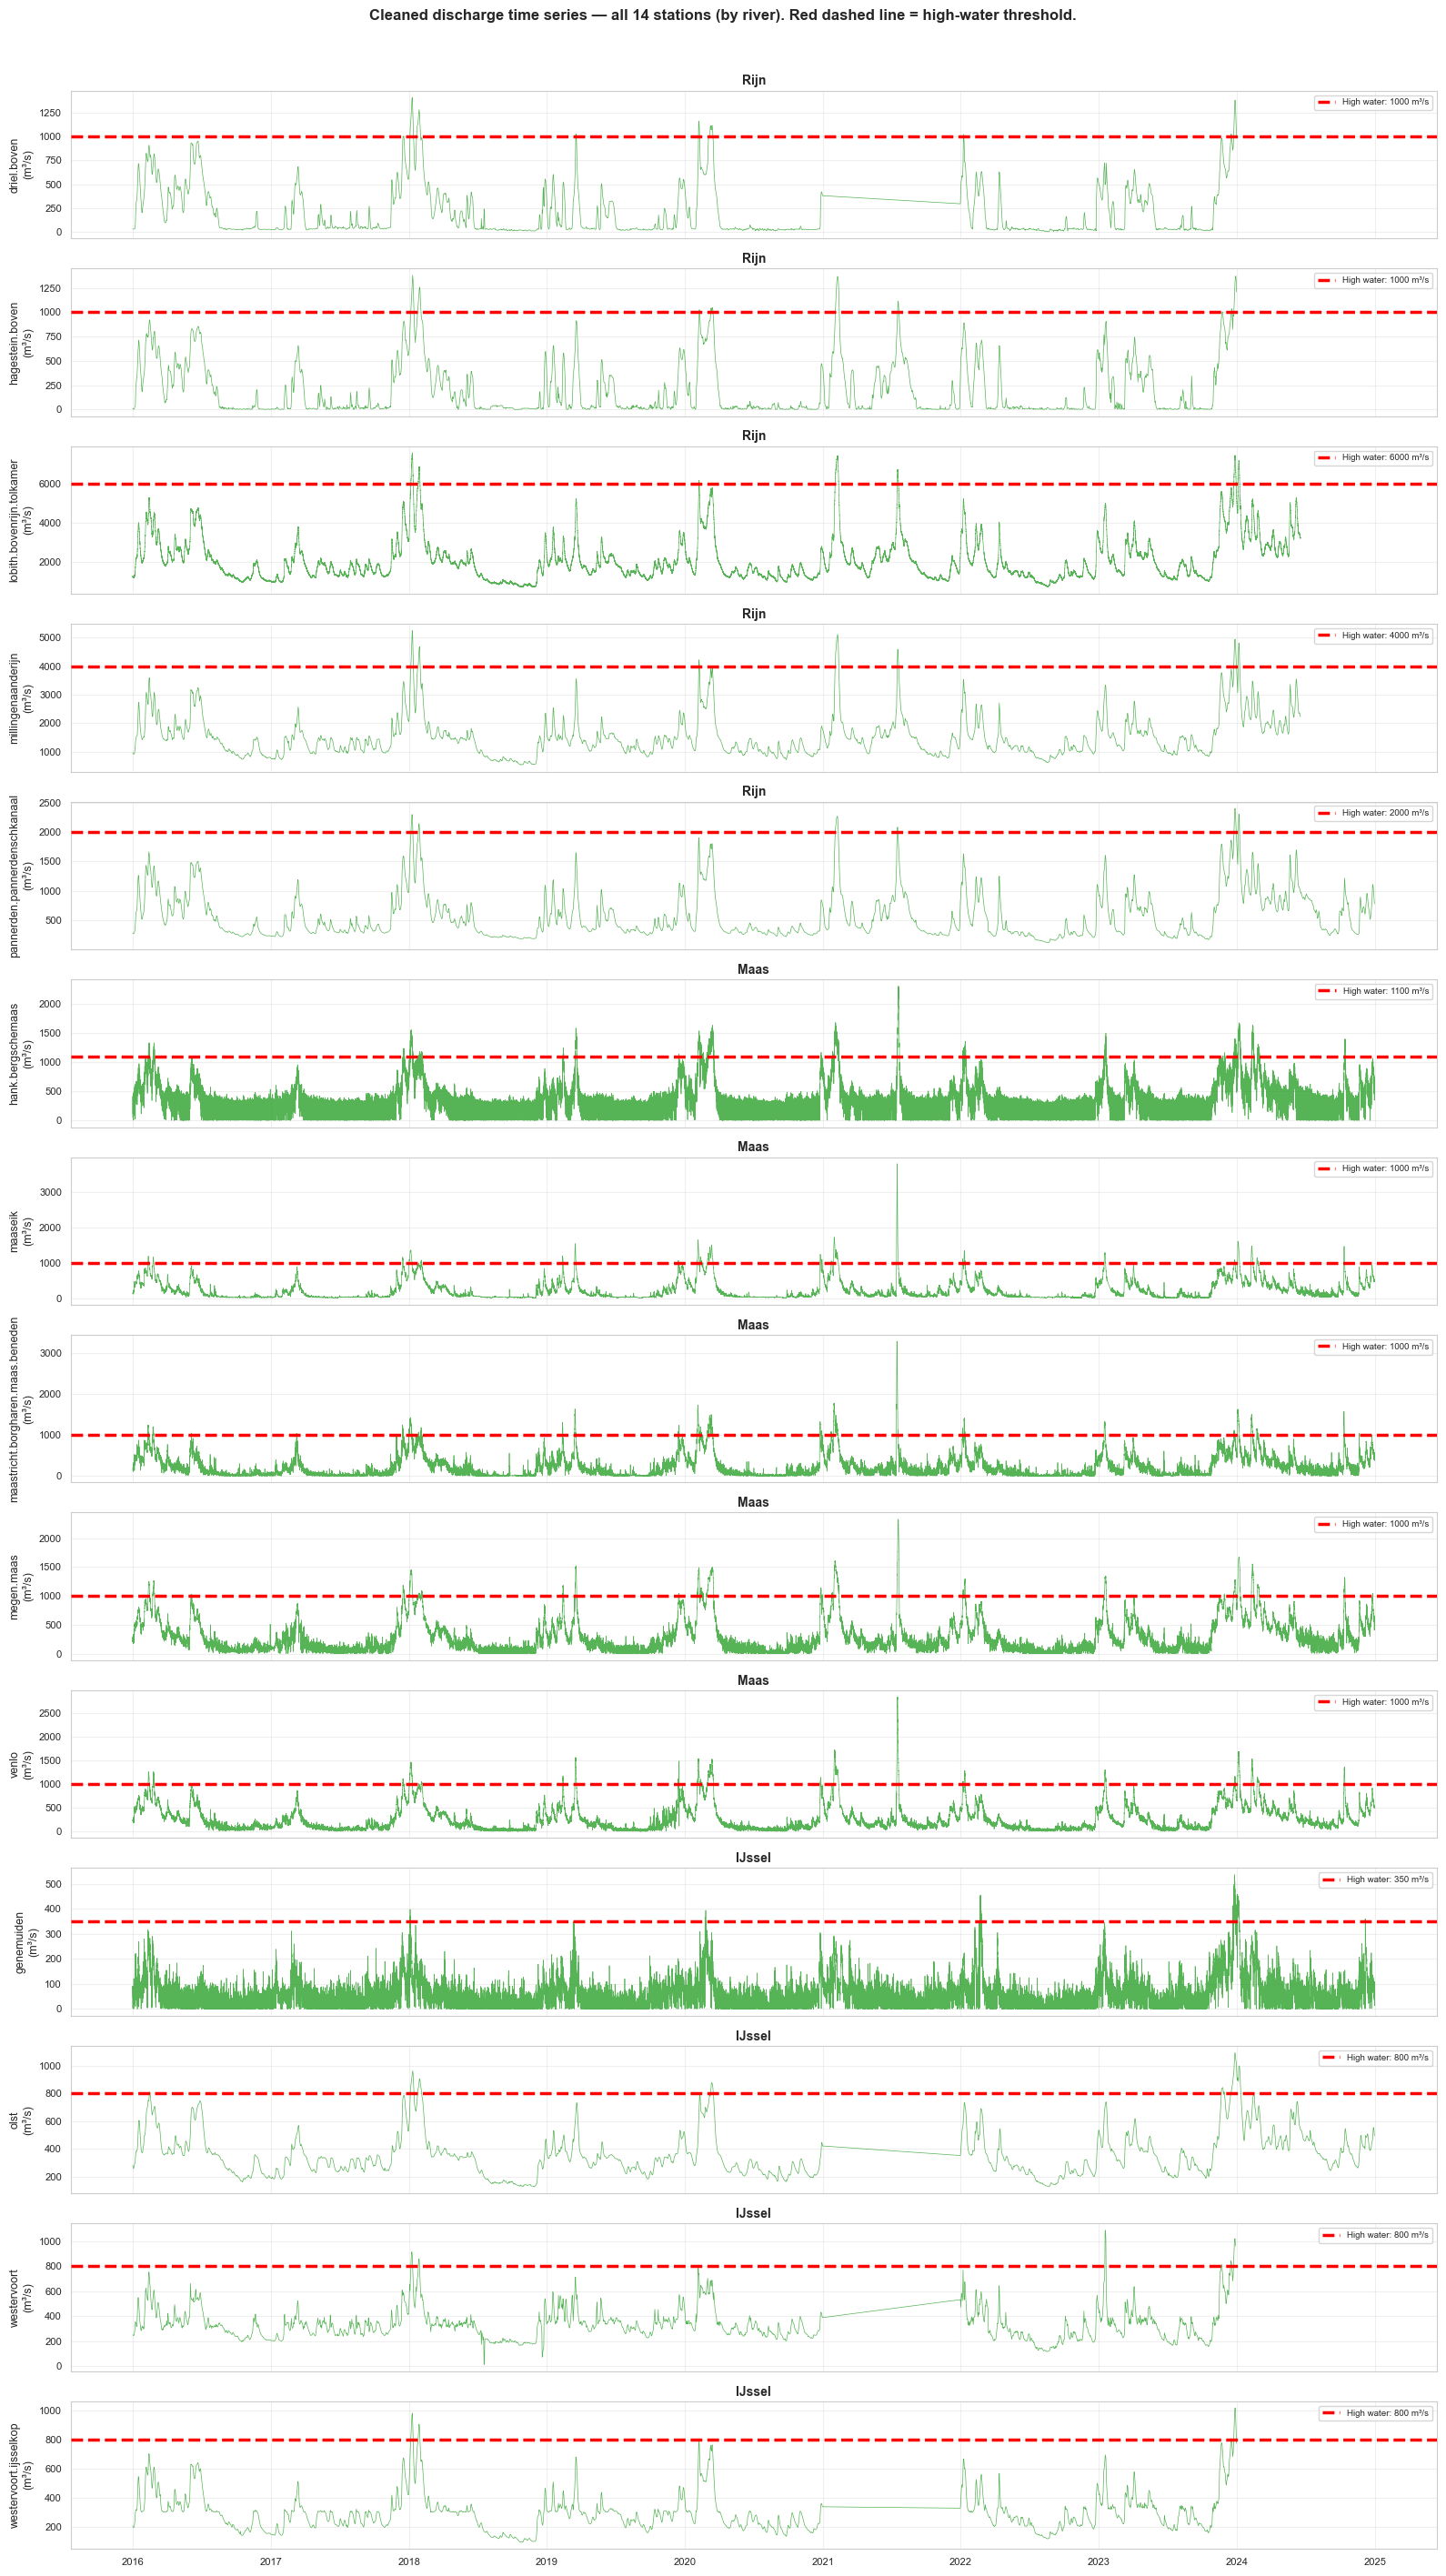

In [32]:
# All 14 cleaned discharge time series stacked vertically, sorted by river
# High-water thresholds (m³/s) — for review before use in feature engineering
HIGH_WATER_THRESHOLD = {
    "lobith.bovenrijn.tolkamer": 6000,
    "millingenaanderijn": 4000,
    "pannerden.pannerdenschkanaal": 2000,
    "driel.boven": 1000,
    "hagestein.boven": 1000,
    "maastricht.borgharen.maas.beneden": 1000,
    "maaseik": 1000,
    "venlo": 1000,
    "megen.maas": 1000,
    "hank.bergschemaas": 1100,
    "westervoort.ijsselkop": 800,
    "westervoort": 800,
    "olst": 800,
    "genemuiden": 350,
}
STATION_RIVER = {
    "lobith.bovenrijn.tolkamer": "Rijn",
    "pannerden.pannerdenschkanaal": "Rijn",
    "millingenaanderijn": "Rijn",
    "driel.boven": "Rijn",
    "hagestein.boven": "Rijn",
    "maastricht.borgharen.maas.beneden": "Maas",
    "maaseik": "Maas",
    "venlo": "Maas",
    "megen.maas": "Maas",
    "hank.bergschemaas": "Maas",
    "westervoort.ijsselkop": "IJssel",
    "westervoort": "IJssel",
    "olst": "IJssel",
    "genemuiden": "IJssel",
}
RIVER_ORDER = ["Rijn", "Maas", "IJssel"]
all_stations = station_info_df["station_code"].unique().tolist()
def _river_sort_key(s):
    river = STATION_RIVER.get(s, "Other")
    ri = RIVER_ORDER.index(river) if river in RIVER_ORDER else 99
    return (ri, s)

stations = sorted(all_stations, key=_river_sort_key)
n_stations = len(stations)

fig, axes = plt.subplots(n_stations, 1, figsize=(16, 2 * n_stations), sharex=True)

for idx, station_code in enumerate(stations):
    ax = axes[idx] if n_stations > 1 else axes
    clean_path = OUTPUT_DIR / f"{station_code}.parquet"
    river = STATION_RIVER.get(station_code, "?")

    if clean_path.exists():
        clean_df = pd.read_parquet(clean_path).sort_values("timestamp")
        ax.plot(clean_df["timestamp"], clean_df["discharge_m3s"], "-", alpha=0.8, linewidth=0.5, c="tab:green")

    threshold = HIGH_WATER_THRESHOLD.get(station_code)
    if threshold is not None:
        ax.axhline(threshold, color="red", linestyle="--", linewidth=2.5, zorder=10, label=f"High water: {threshold} m³/s")
        ymin, ymax = ax.get_ylim()
        if threshold > ymax:
            ax.set_ylim(ymin, threshold * 1.15)
        ax.legend(loc="upper right", fontsize=7)

    ax.set_ylabel(f"{station_code}\n(m³/s)", fontsize=9)
    ax.text(0.5, 1.02, river, transform=ax.transAxes, fontsize=10, fontweight="bold", ha="center", va="bottom")
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Cleaned discharge time series — all 14 stations (by river). Red dashed line = high-water threshold.", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()